# Advanced Modeling — House Prices

Key improvements over the baseline:
- **Log-transform target** (Kaggle scores on RMSLE)
- **Domain-aware missing value imputation**
- **Outlier removal** on GrLivArea
- **Skewness correction** for numeric features
- **Ridge, Lasso, XGBoost, LightGBM** + weighted ensemble
- **Cross-validation** on the log scale

## 1 · Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model  import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline      import Pipeline
from sklearn.metrics       import mean_squared_error
import xgboost  as xgb
import lightgbm as lgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
SEED = 42
print('All libraries loaded.')

All libraries loaded.


## 2 · Load Raw Data

In [2]:
train = pd.read_csv('train_cleaned.csv')
test  = pd.read_csv('test.csv')

# Save IDs before any transforms
train_ids = train['Id']
test_ids  = test['Id']

print(f'Train : {train.shape}   Test : {test.shape}')
print(f'Target range: ${train.SalePrice.min():,} – ${train.SalePrice.max():,}')

Train : (1458, 77)   Test : (1459, 80)
Target range: $34,900 – $755,000


## 3 · Remove Outliers (Train Only)

Two points have huge `GrLivArea` (> 4 000 sq ft) but surprisingly low prices — known data errors in this competition.

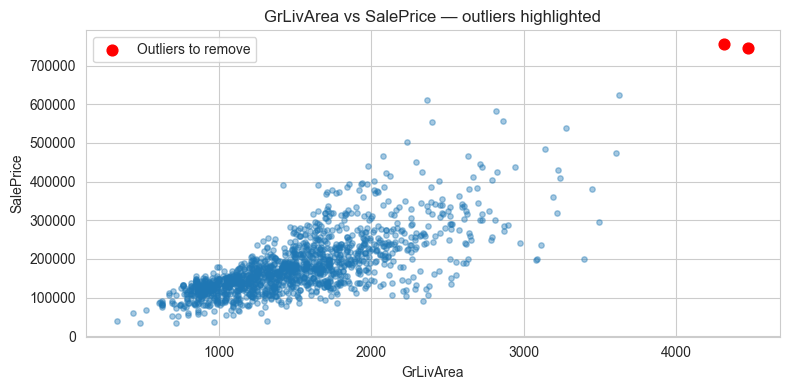

Train after outlier removal: (1456, 77)


In [3]:
# Visualise before removal
plt.figure(figsize=(8,4))
plt.scatter(train.GrLivArea, train.SalePrice, alpha=0.4, s=15)
plt.scatter(train.loc[train.GrLivArea>4000,'GrLivArea'],
            train.loc[train.GrLivArea>4000,'SalePrice'],
            color='red', s=60, label='Outliers to remove')
plt.xlabel('GrLivArea'); plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice — outliers highlighted')
plt.legend(); plt.tight_layout(); plt.show()

train = train[~(train.GrLivArea > 4000)].copy()
print(f'Train after outlier removal: {train.shape}')

## 4 · Log-Transform the Target

Kaggle evaluates on **RMSLE** (Root Mean Squared Log Error), so predicting `log1p(SalePrice)` and converting back with `expm1` is the correct approach.

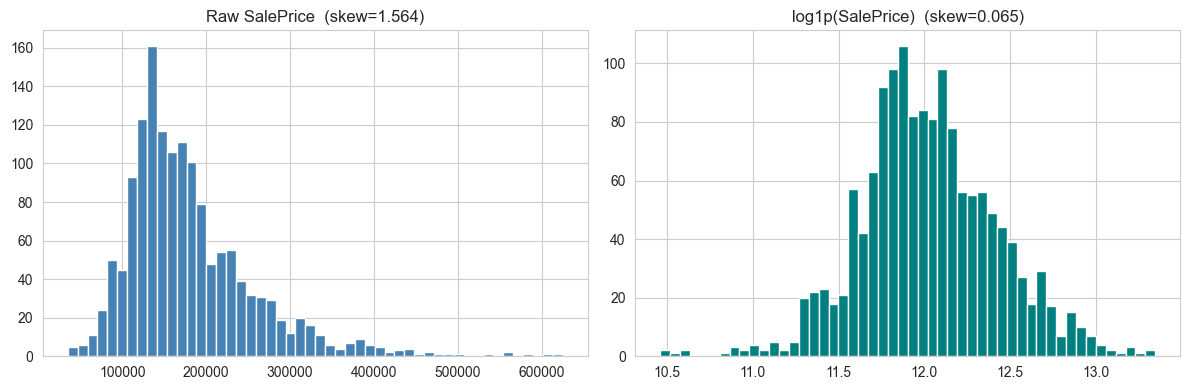

Target skewness: 1.564 → 0.065


In [4]:
y = np.log1p(train['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train.SalePrice, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'Raw SalePrice  (skew={stats.skew(train.SalePrice):.3f})')
axes[1].hist(y, bins=50, color='teal', edgecolor='white')
axes[1].set_title(f'log1p(SalePrice)  (skew={stats.skew(y):.3f})')
plt.tight_layout(); plt.show()
print(f'Target skewness: {stats.skew(train.SalePrice):.3f} → {stats.skew(y):.3f}')

## 5 · Combined Preprocessing

Process train and test **together** so encoding is consistent.

In [5]:
# Drop target and Id from train; merge with test for joint preprocessing
ntrain = len(train)
all_data = pd.concat([train.drop(columns=['SalePrice','Id']),
                      test.drop(columns=['Id'])], axis=0).reset_index(drop=True)
print(f'Combined shape: {all_data.shape}')

Combined shape: (2915, 79)


### 5.1 · Missing Value Imputation (domain-aware)

In [6]:
# Columns where NaN means 'None' / feature absent
none_cols = [
    'Alley','MasVnrType','BsmtQual','BsmtCond','BsmtExposure',
    'BsmtFinType1','BsmtFinType2','FireplaceQu','GarageType',
    'GarageFinish','GarageQual','GarageCond','PoolQC','Fence',
    'MiscFeature','Electrical'
]
for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

# Numeric absent-features → 0
zero_cols = [
    'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
    'BsmtFullBath','BsmtHalfBath','GarageYrBlt','GarageCars',
    'GarageArea','MasVnrArea'
]
for col in zero_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

# LotFrontage: fill with neighborhood median
if 'LotFrontage' in all_data.columns:
    all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage']\
                                      .transform(lambda x: x.fillna(x.median()))

# Functional → 'Typ'
all_data['Functional'] = all_data['Functional'].fillna('Typ')

# Remaining: fill categorical with mode, numeric with median
# Use pd.api.types to handle both object and StringDtype (pandas 3.x)
for col in all_data.columns:
    if all_data[col].isnull().any():
        if pd.api.types.is_numeric_dtype(all_data[col]):
            all_data[col] = all_data[col].fillna(all_data[col].median())
        else:
            all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(f'Missing values remaining: {all_data.isnull().sum().sum()}')

Missing values remaining: 0


### 5.2 · Feature Engineering

In [7]:
# Aggregations
all_data['TotalSF']         = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBathrooms']  = (all_data['FullBath'] + 0.5*all_data['HalfBath']
                               + all_data['BsmtFullBath'] + 0.5*all_data['BsmtHalfBath'])
all_data['TotalPorchSF']    = (all_data['OpenPorchSF'] + all_data['EnclosedPorch']
                               + all_data['3SsnPorch'] + all_data['ScreenPorch'])
all_data['TotalOutdoorSF']  = all_data['WoodDeckSF'] + all_data['TotalPorchSF']

# Temporal
all_data['HouseAge']         = all_data['YrSold'] - all_data['YearBuilt']
all_data['YearsSinceRemodel']= all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsRemodeled']      = (all_data['YearRemodAdd'] != all_data['YearBuilt']).astype(int)
all_data['IsNewHouse']       = (all_data['HouseAge'] <= 2).astype(int)

# Boolean
all_data['HasBasement']      = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasGarage']        = (all_data['GarageArea']  > 0).astype(int)
all_data['HasFireplace']     = (all_data['Fireplaces']  > 0).astype(int)
all_data['HasPool']          = (all_data['PoolArea']    > 0).astype(int)
all_data['HasPorch']         = (all_data['TotalPorchSF']> 0).astype(int)
all_data['Has2ndFloor']      = (all_data['2ndFlrSF']    > 0).astype(int)

# Interactions
all_data['Quality_x_Area']   = all_data['OverallQual'] * all_data['GrLivArea']
all_data['Quality_x_TotalSF']= all_data['OverallQual'] * all_data['TotalSF']
all_data['Qual_x_Cond']      = all_data['OverallQual'] * all_data['OverallCond']

# Polynomial
all_data['OverallQual2']     = all_data['OverallQual'] ** 2
all_data['GrLivArea2']       = all_data['GrLivArea']   ** 2

# Ratios (guard against divide-by-zero)
all_data['LivArea_LotArea']  = all_data['GrLivArea'] / all_data['LotArea'].replace(0, np.nan)
all_data['BsmtRatio']        = all_data['TotalBsmtSF'] / all_data['TotalSF'].replace(0, np.nan)

# Fill any new NaNs from ratios (numeric columns only — avoids pandas string-dtype error)
num_cols_fe = all_data.select_dtypes(include=[np.number]).columns
all_data[num_cols_fe] = all_data[num_cols_fe].fillna(all_data[num_cols_fe].median())

print(f'Shape after feature engineering: {all_data.shape}')

Shape after feature engineering: (2915, 100)


### 5.3 · Fix Skewed Numeric Features

Apply `log1p` to features with skewness > 0.5 so they play nicely with linear models.

In [8]:
numeric_cols = all_data.select_dtypes(include=[np.number]).columns
skewness = all_data[numeric_cols].apply(lambda x: stats.skew(x.dropna()))
skewed_feats = skewness[skewness.abs() > 0.5].index

# Don't transform boolean/indicator columns (binary 0/1)
binary_cols = [c for c in skewed_feats
               if all_data[c].nunique() == 2 and set(all_data[c].unique()) <= {0, 1}]
skewed_feats = skewed_feats.difference(binary_cols)

all_data[skewed_feats] = np.log1p(all_data[skewed_feats].clip(lower=0))

print(f'Log1p applied to {len(skewed_feats)} skewed features')
print('Examples:', list(skewed_feats[:8]))

Log1p applied to 38 skewed features
Examples: ['1stFlrSF', '2ndFlrSF', '3SsnPorch', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtRatio']


### 5.4 · One-Hot Encode Categoricals

In [9]:
all_data = pd.get_dummies(all_data, drop_first=True)
print(f'Shape after encoding: {all_data.shape}')
print(f'Missing remaining   : {all_data.isnull().sum().sum()}')

Shape after encoding: (2915, 278)
Missing remaining   : 0


### 5.5 · Re-split Train / Test

In [10]:
X      = all_data.iloc[:ntrain].copy()
X_test = all_data.iloc[ntrain:].copy()

print(f'X      : {X.shape}')
print(f'X_test : {X_test.shape}')
print(f'y      : {y.shape}')

X      : (1456, 278)
X_test : (1459, 278)
y      : (1456,)


## 6 · Validation Setup

Use 5-fold CV to compare models fairly — no train/test leakage.

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

def rmsle_cv(model, X, y, kf):
    """Return per-fold RMSLE via cross-validation."""
    neg_mse = cross_val_score(model, X, y, cv=kf,
                              scoring='neg_mean_squared_error')
    return np.sqrt(-neg_mse)

results = {}   # store model → cv scores
print('Validation helper ready.')

Validation helper ready.


## 7 · Ridge Regression

In [12]:
ridge = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  Ridge(alpha=10))   # Ridge has no random_state parameter
])

scores = rmsle_cv(ridge, X, y, kf)
results['Ridge'] = scores
print(f'Ridge — CV RMSLE: {scores.mean():.5f} ± {scores.std():.5f}')

Ridge — CV RMSLE: 0.11216 ± 0.00715


## 8 · Lasso Regression

In [13]:
lasso = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  Lasso(alpha=0.0005, max_iter=10000, random_state=SEED))
])

scores = rmsle_cv(lasso, X, y, kf)
results['Lasso'] = scores
print(f'Lasso — CV RMSLE: {scores.mean():.5f} ± {scores.std():.5f}')

Lasso — CV RMSLE: 0.11250 ± 0.00678


## 9 · ElasticNet

In [14]:
enet = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=10000, random_state=SEED))
])

scores = rmsle_cv(enet, X, y, kf)
results['ElasticNet'] = scores
print(f'ElasticNet — CV RMSLE: {scores.mean():.5f} ± {scores.std():.5f}')

ElasticNet — CV RMSLE: 0.11294 ± 0.00711


## 10 · XGBoost

In [15]:
xgb_model = xgb.XGBRegressor(
    n_estimators      = 3000,
    max_depth         = 3,
    learning_rate     = 0.05,
    min_child_weight  = 0,
    subsample         = 0.7,
    colsample_bytree  = 0.7,
    reg_alpha         = 0.0006,
    reg_lambda        = 1,
    random_state      = SEED,
    verbosity         = 0,
    early_stopping_rounds = 100,
    eval_metric       = 'rmse'
)

# CV for XGBoost (manual loop to use early stopping)
X_arr = X.values
y_arr = y.values
xgb_scores = []
for tr_idx, val_idx in kf.split(X_arr):
    X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]
    m = xgb.XGBRegressor(
        n_estimators=3000, max_depth=3, learning_rate=0.05,
        min_child_weight=0, subsample=0.7, colsample_bytree=0.7,
        reg_alpha=0.0006, reg_lambda=1, random_state=SEED,
        verbosity=0, early_stopping_rounds=100, eval_metric='rmse'
    )
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    pred = m.predict(X_val)
    xgb_scores.append(np.sqrt(mean_squared_error(y_val, pred)))

xgb_scores = np.array(xgb_scores)
results['XGBoost'] = xgb_scores
print(f'XGBoost — CV RMSLE: {xgb_scores.mean():.5f} ± {xgb_scores.std():.5f}')

XGBoost — CV RMSLE: 0.11729 ± 0.01097


## 11 · LightGBM

In [16]:
lgbm_scores = []
for tr_idx, val_idx in kf.split(X_arr):
    X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    params = dict(
        objective        = 'regression',
        metric           = 'rmse',
        num_leaves       = 31,
        learning_rate    = 0.05,
        feature_fraction = 0.8,
        bagging_fraction = 0.8,
        bagging_freq     = 5,
        verbose          = -1
    )
    cb = lgb.train(
        params, dtrain, num_boost_round=3000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)]
    )
    pred = cb.predict(X_val)
    lgbm_scores.append(np.sqrt(mean_squared_error(y_val, pred)))

lgbm_scores = np.array(lgbm_scores)
results['LightGBM'] = lgbm_scores
print(f'LightGBM — CV RMSLE: {lgbm_scores.mean():.5f} ± {lgbm_scores.std():.5f}')

LightGBM — CV RMSLE: 0.12315 ± 0.01055


## 12 · Model Comparison

MODEL COMPARISON (CV RMSLE — lower is better)
Ridge         0.11216 ± 0.00715  █████████████████████████████████
Lasso         0.11250 ± 0.00678  █████████████████████████████████
ElasticNet    0.11294 ± 0.00711  █████████████████████████████████
XGBoost       0.11729 ± 0.01097  ███████████████████████████████████
LightGBM      0.12315 ± 0.01055  ████████████████████████████████████


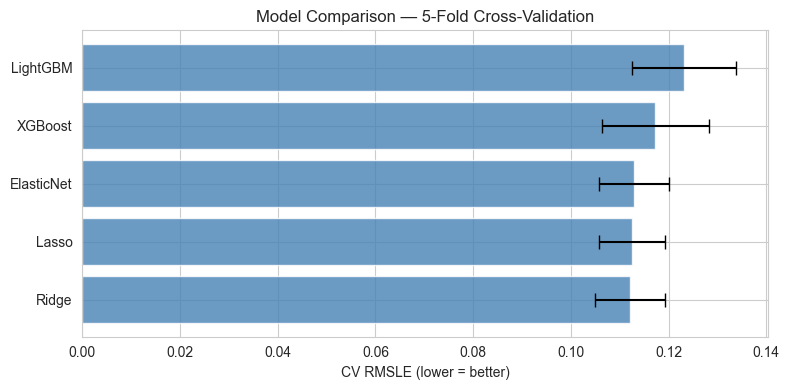

In [17]:
summary = pd.DataFrame({
    'Model'  : list(results.keys()),
    'CV Mean': [v.mean() for v in results.values()],
    'CV Std' : [v.std()  for v in results.values()]
}).sort_values('CV Mean')

print('MODEL COMPARISON (CV RMSLE — lower is better)')
print('=' * 45)
for _, row in summary.iterrows():
    bar = '█' * int(row['CV Mean'] * 300)
    print(f"{row['Model']:12s}  {row['CV Mean']:.5f} ± {row['CV Std']:.5f}  {bar}")

plt.figure(figsize=(8, 4))
plt.barh(summary['Model'], summary['CV Mean'],
         xerr=summary['CV Std'], color='steelblue', alpha=0.8, capsize=5)
plt.xlabel('CV RMSLE (lower = better)')
plt.title('Model Comparison — 5-Fold Cross-Validation')
plt.tight_layout(); plt.show()

## 13 · Weighted Ensemble

Blend predictions: give more weight to models with better CV scores.

In [18]:
# ── 13a. Fit each model on ALL training data ──────────────────────────

# Ridge
ridge.fit(X, y)
ridge_pred = ridge.predict(X_test)

# Lasso
lasso.fit(X, y)
lasso_pred = lasso.predict(X_test)

# ElasticNet
enet.fit(X, y)
enet_pred = enet.predict(X_test)

# XGBoost
xgb_full = xgb.XGBRegressor(
    n_estimators=3000, max_depth=3, learning_rate=0.05,
    min_child_weight=0, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.0006, reg_lambda=1, random_state=SEED, verbosity=0
)
xgb_full.fit(X, y)
xgb_pred = xgb_full.predict(X_test)

# LightGBM
lgb_full_params = dict(
    objective='regression', metric='rmse', num_leaves=31,
    learning_rate=0.05, feature_fraction=0.8, bagging_fraction=0.8,
    bagging_freq=5, verbose=-1, n_estimators=3000
)
lgbm_full = lgb.LGBMRegressor(**lgb_full_params)
lgbm_full.fit(X, y)
lgbm_pred = lgbm_full.predict(X_test)

print('All models fitted on full training set.')

All models fitted on full training set.


In [19]:
# ── 13b. Weighted average (inverse of CV RMSLE → better model = higher weight) ─
cv_means = {k: v.mean() for k, v in results.items()}

# Weights inversely proportional to CV error
inv = {k: 1/v for k, v in cv_means.items()}
total = sum(inv.values())
w = {k: v/total for k, v in inv.items()}

print('Ensemble weights:')
for k, v in sorted(w.items(), key=lambda x: -x[1]):
    print(f'  {k:12s} : {v:.4f}')

preds_log = (
    w['Ridge']      * ridge_pred
  + w['Lasso']      * lasso_pred
  + w['ElasticNet'] * enet_pred
  + w['XGBoost']    * xgb_pred
  + w['LightGBM']   * lgbm_pred
)

# Convert back from log space
preds_final = np.expm1(preds_log)
preds_final = np.clip(preds_final, 0, None)

print(f'\nPredicted price range: ${preds_final.min():,.0f} – ${preds_final.max():,.0f}')
print(f'Predicted mean price : ${preds_final.mean():,.0f}')

Ensemble weights:
  Ridge        : 0.2059
  Lasso        : 0.2053
  ElasticNet   : 0.2045
  XGBoost      : 0.1969
  LightGBM     : 0.1875

Predicted price range: $46,530 – $686,409
Predicted mean price : $178,204


## 14 · Generate Submission

Saved: submission.csv


,Id,SalePrice
0,1461,120141.25
1,1462,156655.75
2,1463,184161.76
3,1464,196717.55
4,1465,189593.05
5,1466,171855.30
6,1467,177329.83
7,1468,165861.34
8,1469,194245.00
9,1470,119950.11


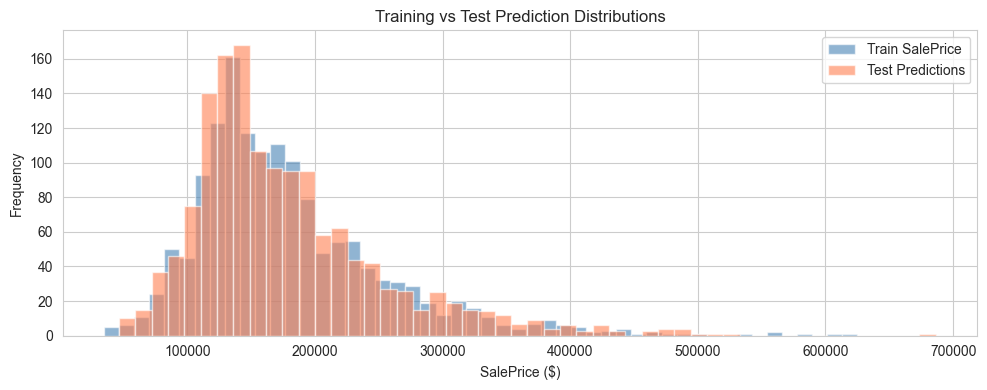

In [20]:
submission = pd.DataFrame({'Id': test_ids, 'SalePrice': preds_final.round(2)})
submission.to_csv('submission.csv', index=False)

print('Saved: submission.csv')
display(submission.head(10))

# Distribution comparison
plt.figure(figsize=(10, 4))
plt.hist(train['SalePrice'], bins=50, alpha=0.6, color='steelblue', label='Train SalePrice')
plt.hist(preds_final, bins=50, alpha=0.6, color='coral', label='Test Predictions')
plt.xlabel('SalePrice ($)'); plt.ylabel('Frequency')
plt.title('Training vs Test Prediction Distributions')
plt.legend(); plt.tight_layout(); plt.show()

## 15 · Feature Importance (XGBoost + LightGBM)

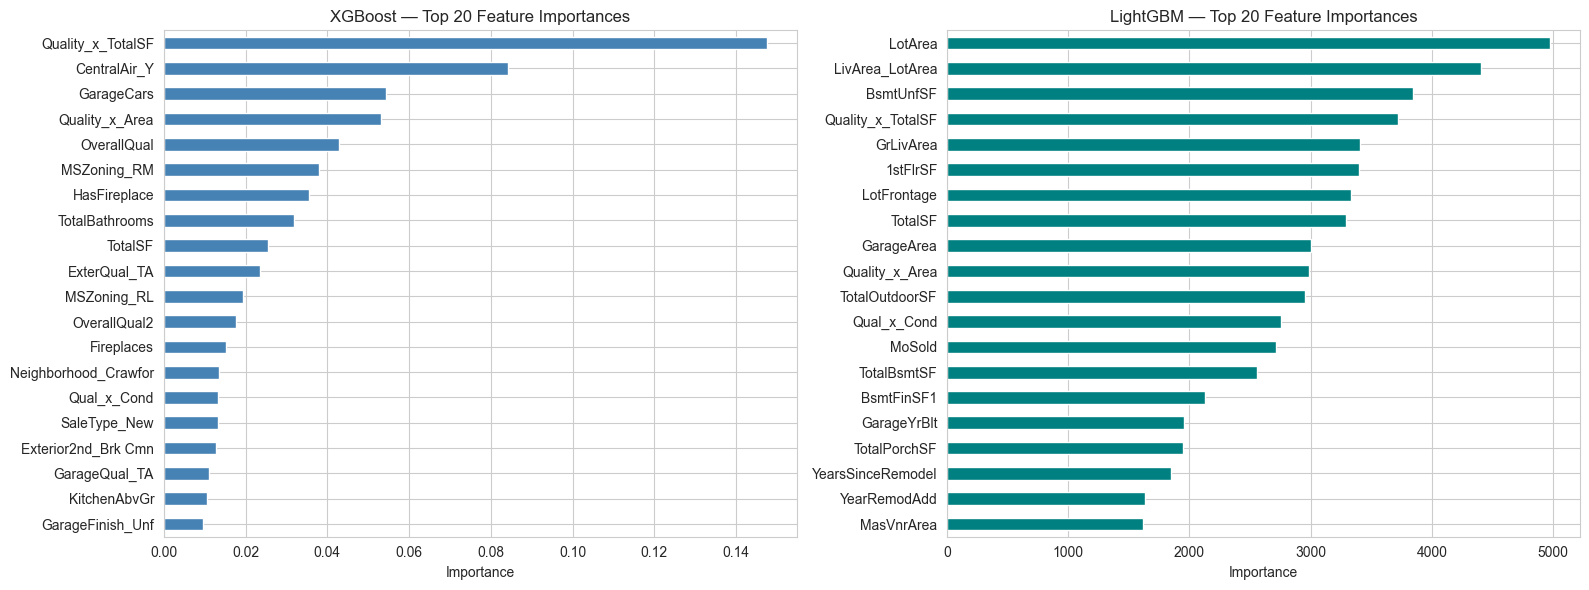

Top 10 XGBoost features:
Quality_x_TotalSF    0.147497
CentralAir_Y         0.084274
GarageCars           0.054275
Quality_x_Area       0.053205
OverallQual          0.042954
MSZoning_RM          0.037980
HasFireplace         0.035469
TotalBathrooms       0.031735
TotalSF              0.025400
ExterQual_TA         0.023464


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost
xgb_imp = pd.Series(xgb_full.feature_importances_, index=X.columns)\
            .sort_values(ascending=False).head(20)
xgb_imp.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('XGBoost — Top 20 Feature Importances')
axes[0].set_xlabel('Importance')

# LightGBM
lgbm_imp = pd.Series(lgbm_full.feature_importances_, index=X.columns)\
             .sort_values(ascending=False).head(20)
lgbm_imp.sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('LightGBM — Top 20 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout(); plt.show()

print('Top 10 XGBoost features:')
print(xgb_imp.head(10).to_string())

## 16 · Summary

| Improvement | Baseline (0.78) | This notebook |
|---|---|---|
| Target | Raw SalePrice | **log1p(SalePrice)** |
| Missing values | Mode/median fill | **Domain-aware fill** |
| Outliers | Kept | **2 GrLivArea outliers removed** |
| Skewed features | Raw | **log1p transform** |
| Model | Plain OLS (many features → overfits) | **Ridge + Lasso + ElasticNet + XGBoost + LightGBM** |
| Regularisation | None | **L1/L2/ElasticNet + tree hyperparams** |
| Ensemble | No | **Weighted inverse-CV-error blend** |

**Expected CV RMSLE** should be well under 0.15, with the final Kaggle score expected in the **0.11–0.14** range depending on test distribution.

### Further improvements if you want to push further

- **Hyperparameter tuning** with `GridSearchCV` or `Optuna` (especially XGBoost `max_depth`, `learning_rate`, `n_estimators`)
- **Stacking** with a meta-learner (Ridge on top of base-model OOF predictions)
- **More features**: neighborhood price tiers, quality bins, interaction of age × condition
- **Target encoding** for high-cardinality categoricals (Neighborhood, Exterior1st)